In [3]:
!pip install google-play-scraper

In [4]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

In [5]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

In [6]:
import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

In [7]:
!pip install sastrawi

In [8]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

In [9]:
!pip install wordcloud 

In [10]:
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to C:\Users\Rahmad
[nltk_data]     Riyadi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Rahmad
[nltk_data]     Riyadi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews_all, Sort

In [ ]:
scrapreview = reviews_all(
    'com.ruangguru.livestudents', #id aplikasi ruangguru
    lang='id',                 
    country='id',              
    sort=Sort.MOST_RELEVANT,   # Mengambil ulasan yang paling relevan
    count=10000                
)

# Memasukkan hasil scraping ke dalam DataFrame Pandas
app_reviews_df = pd.DataFrame(scrapreview)

# Menyimpan DataFrame ke file CSV 
app_reviews_df.to_csv('ulasan_aplikasi_edukasi.csv', index=False)

print(f"Jumlah ulasan yang berhasil diambil: {app_reviews_df.shape[0]}")
app_reviews_df.head()

Jumlah ulasan yang berhasil diambil: 240312


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,29f3a56a-6e41-448f-8431-622ec126443a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saat pakai fitur drill, soal yang berbentuk ta...",5,21,7.0.13,2026-04-16 07:18:35,Maaf ya belajarnya jadi terhambat. Kendala tab...,2026-04-16 14:48:55,7.0.13
1,977df0ce-ffc9-40a7-8856-a6594aaa92d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,overall aplikasi yang bagus hanya saja belum f...,4,1,7.0.13,2026-04-05 21:43:56,Maaf ya belajarnya jadi terhambat 🙏 Kendala ja...,2026-04-06 12:07:09,7.0.13
2,24022a76-cd9c-4122-bd6f-5fecf2e97e14,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aku suka banget sama apk bimbel ini, pembelaja...",5,7,7.0.13,2026-04-07 15:40:10,Ikut happy kalau belajarnya terasa mudah dipah...,2026-04-07 17:31:37,7.0.13
3,afb414bf-b47d-4fc8-999f-12315f6a16c8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi Ruangguru sering lemot dan sering buf...,3,12,7.0.13,2026-03-12 08:26:29,"Kendala bug-nya seperti apa nih, Akhdar? Maaf ...",2026-03-12 12:37:12,7.0.13
4,f217b92f-1beb-40c7-b2f2-6faf8a3c2eeb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ruangguru knpsih kuisnya di ruangbelajar selal...,2,8,7.0.13,2026-04-20 21:11:33,Maaf ya belajar Aulia jadi nggak nyaman 🙏 Kend...,2026-04-23 11:36:43,7.0.13


In [16]:
print('Cek Informasi Awal Dataset')
app_reviews_df.info()

Cek Informasi Awal Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240312 entries, 0 to 240311
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              240312 non-null  object        
 1   userName              240312 non-null  object        
 2   userImage             240312 non-null  object        
 3   content               240307 non-null  object        
 4   score                 240312 non-null  int64         
 5   thumbsUpCount         240312 non-null  int64         
 6   reviewCreatedVersion  155405 non-null  object        
 7   at                    240312 non-null  datetime64[ns]
 8   replyContent          238125 non-null  object        
 9   repliedAt             238125 non-null  datetime64[ns]
 10  appVersion            155405 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 20.2+ MB


## Cleaning Data

In [ ]:
# Menghapus nilai NAN yang ada di kolom ulasan
clean_df = app_reviews_df.dropna(subset=['content'])

# Menghapus baris yang duplikat
clean_df = app_reviews_df.drop_duplicates(subset=['content'])

In [18]:
# Mengambil kolom yang akan kita gunakan
clean_df = clean_df[['content', 'score']]

jumlah_ulasan_bersih, jumlah_kolom_bersih = clean_df.shape
print('Jumlah data setelah cleaning =', jumlah_ulasan_bersih, 'baris')

clean_df.head()

Jumlah data setelah cleaning = 240307 baris


,content,score
0,"Saat pakai fitur drill, soal yang berbentuk ta...",5
1,overall aplikasi yang bagus hanya saja belum f...,4
2,"aku suka banget sama apk bimbel ini, pembelaja...",5
3,Aplikasi Ruangguru sering lemot dan sering buf...,3
4,Ruangguru knpsih kuisnya di ruangbelajar selal...,2


Melakukan Pelebelan Data
- Bintang 1 dan 2 akan melambangkan sentimen negatif
- Bintang 3 akan menjadi lambang sentimen netral, dan
- Bintang 4 dan 5 sebagai sentimen positif

In [19]:
def konversi_label(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'
    

# Menerapkan fungsi
clean_df['label'] = clean_df['score'].apply(konversi_label)

print('Distribusi Kelas Sentimen')
print(clean_df['label'].value_counts())

clean_df[['content', 'score', 'label']].head()

Distribusi Kelas Sentimen
label
Positif    211907
Negatif     19791
Netral       8609
Name: count, dtype: int64


,content,score,label
0,"Saat pakai fitur drill, soal yang berbentuk ta...",5,Positif
1,overall aplikasi yang bagus hanya saja belum f...,4,Positif
2,"aku suka banget sama apk bimbel ini, pembelaja...",5,Positif
3,Aplikasi Ruangguru sering lemot dan sering buf...,3,Netral
4,Ruangguru knpsih kuisnya di ruangbelajar selal...,2,Negatif


## Teks Preprocessing

In [ ]:
# Inisialisasi Stemmer dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [24]:
# daftar Stopword (Kata umum yang dibuang)
list_stopwords =  set(stopwords.words('indonesian'))
# tambah kata gaul baru
list_stopwords.update(['nya', 'yg', 'di', 'ke', 'dari', 'dan', 'ini', 'itu', 'aplikasi', 'rg', 'ruangguru', 'ya', 'aja', 'sih', 'kok'])

In [ ]:
# Kelas Netral langsung di Buang karena pengalaman train sebelumnya tidak memuaskan
clean_df_biner = clean_df[clean_df['label'] != 'Netral'].copy()

# Menyeimbangkan kelas Negatif dan Positif
jumlah_minimal = clean_df_biner['label'].value_counts().min()

df_positif = clean_df_biner[clean_df_biner['label'] == 'Positif'].sample(jumlah_minimal, random_state=42)
df_negatif = clean_df_biner[clean_df_biner['label'] == 'Negatif'].sample(jumlah_minimal, random_state=42)

balanced_df = pd.concat([df_positif, df_negatif])

#Mengacak ulang urutan barisnya agar variatif
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Mengecek hasil akhirnya
print("Distribusi Data Biner Setelah Diseimbangkan:")
print(balanced_df['label'].value_counDts())

Distribusi Data Biner Setelah Diseimbangkan:
label
Negatif    19791
Positif    19791
Name: count, dtype: int64


In [42]:
def text_preprocessing(text):

    # Case Folding dan Cleaning
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # hapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # hapus hashtag
    text = re.sub(r'http\S+', '', text) # hapus link
    text = re.sub(r'[0-9]+', '', text) # hapus angka
    text = re.sub(r'[^\w\s]', '', text) # hapus tanda baca
    text = text.replace('\n', ' ').strip()

    # Tokenizing
    tokens = word_tokenize(text)

    # Filtering (stopword)
    tokens = [word for word in tokens if word not in list_stopwords]
    
    # Stemming (Sastrawi)
    tokens = [stemmer.stem(word) for word in tokens]
    
    # Menggabungkan kembali menjadi kalimat utuh (toSentence)
    return ' '.join(tokens)


balanced_df['clean_text'] = balanced_df['content'].apply(text_preprocessing)

balanced_df[['content', 'clean_text', 'label']].head(10)

,content,clean_text,label
0,Buruk anying,buruk anying,Negatif
1,Top,top,Positif
2,"Jelek Roboguru plus nya,nanya soal ga dibantu ,malah koin nya hilang",jelek roboguru plus nyana ga bantu koin hilang,Negatif
3,ruang guru pintar sekali ﻿GOOD 😊 MORNING! ☁✨✨☁✨✨☁ ✨✨✨✨✨✨✨ ✨✨✨✨✨✨✨ ☁✨✨✨✨✨☁ ☁☁✨✨✨☁☁ ☁☁☁✨☁☁☁ 🌻 MY SUNSHINE,ruang guru pintar good morning my sunshine,Negatif
4,kelas 10 jurusan akutansi kog gk ada ya mohon infonya,kelas jurus akutansi kog gk mohon info,Negatif
5,Ini bayar ya pakek pulsa apa transfer,bayar pakek pulsa transfer,Negatif
6,Lengkap banget fitur belajarnya dan juga berani masi,lengkap banget fitur ajar berani mas,Positif
7,Kurang ajar sia sia gue belajar gak guna nih ruang guru palsu semua😈,ajar sia sia gue ajar gak nih ruang guru palsu,Negatif
8,Sangat membantu,bantu,Positif
9,"assalamualaikum kak,di fitur robo guru itu gunanya apa sih? kok aku foto soal aku dari kemarin kok gak bisa dijawab,katanya foto tidak jelas PADAHAL AKU PAKAI OPPO A37F DENGAN KUALITAS 1080P. TOLONG DONG ITU DI FIXX TOLONG BANGETTT",assalamualaikum kakdi fitur robo guru guna foto kemarin gak dijawabkatanya foto pakai oppo af kualitas p tolong fixx tolong bangettt,Negatif


In [46]:
balanced_df['word_count'] = balanced_df['content'].apply(lambda x: len(str(x).split()))

# Hanya ambil ulasan yang punya minimal 4 kata
df_filtered = balanced_df[balanced_df['word_count'] >= 4].copy()
df_filtered = df_filtered.drop_duplicates(subset=['content'])

print("Total Data Biner Mentah:", len(balanced_df))
print("Total Data Biner Setelah Filter:", len(df_filtered))

Total Data Biner Mentah: 39582
Total Data Biner Setelah Filter: 27181


In [52]:
df_filtered[['content', 'clean_text', 'label']].head(10)

,content,clean_text,label
2,"Jelek Roboguru plus nya,nanya soal ga dibantu ,malah koin nya hilang",jelek roboguru plus nyana ga bantu koin hilang,Negatif
3,ruang guru pintar sekali ﻿GOOD 😊 MORNING! ☁✨✨☁✨✨☁ ✨✨✨✨✨✨✨ ✨✨✨✨✨✨✨ ☁✨✨✨✨✨☁ ☁☁✨✨✨☁☁ ☁☁☁✨☁☁☁ 🌻 MY SUNSHINE,ruang guru pintar good morning my sunshine,Negatif
4,kelas 10 jurusan akutansi kog gk ada ya mohon infonya,kelas jurus akutansi kog gk mohon info,Negatif
5,Ini bayar ya pakek pulsa apa transfer,bayar pakek pulsa transfer,Negatif
6,Lengkap banget fitur belajarnya dan juga berani masi,lengkap banget fitur ajar berani mas,Positif
7,Kurang ajar sia sia gue belajar gak guna nih ruang guru palsu semua😈,ajar sia sia gue ajar gak nih ruang guru palsu,Negatif
9,"assalamualaikum kak,di fitur robo guru itu gunanya apa sih? kok aku foto soal aku dari kemarin kok gak bisa dijawab,katanya foto tidak jelas PADAHAL AKU PAKAI OPPO A37F DENGAN KUALITAS 1080P. TOLONG DONG ITU DI FIXX TOLONG BANGETTT",assalamualaikum kakdi fitur robo guru guna foto kemarin gak dijawabkatanya foto pakai oppo af kualitas p tolong fixx tolong bangettt,Negatif
10,Aku kasih 2 dulu soalnya aku belum pernah coba apk ini 😊😊😊,kasih coba apk,Negatif
11,maaf saya enggak punya duit segitu kapi saya suka ruang guru nya terima kasih ruangguru!,maaf duit segitu kapi suka ruang guru terima kasih,Negatif
13,"Aplikasinya bagus,tapi kalau gak langanan langsung di spam",aplikasi bagustapi gak langanan langsung spam,Negatif


In [55]:
print("Distribusi setelah difilter")
print(df_filtered['label'].value_counts())

jumlah_minimal_baru = df_filtered['label'].value_counts().min()

df_positif_baru = df_filtered[df_filtered['label'] == 'Positif'].sample(jumlah_minimal_baru, random_state=42)
df_negatif_baru = df_filtered[df_filtered['label'] == 'Negatif'].sample(jumlah_minimal_baru, random_state=42)

df_final_bersih = pd.concat([df_positif_baru, df_negatif_baru]).sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 30)
print("Distribusi Final:")
print(df_final_bersih['label'].value_counts())

Distribusi setelah difilter
label
Negatif    15131
Positif    12050
Name: count, dtype: int64
Distribusi Final:
label
Positif    12050
Negatif    12050
Name: count, dtype: int64


seharusnya melakukan filter dulu sebelum diseimbangkan, namun karena memakan waktu lama jika saya mengulang (laptop kentang) maka saya putuskan untuk menyeimbangkannya lagi

In [58]:
df_final_bersih.to_csv('ruangguru_cleaned_balanced.csv', index=False)
print("Data bersih berhasil diamankan")

Data bersih berhasil diamankan


## EDA

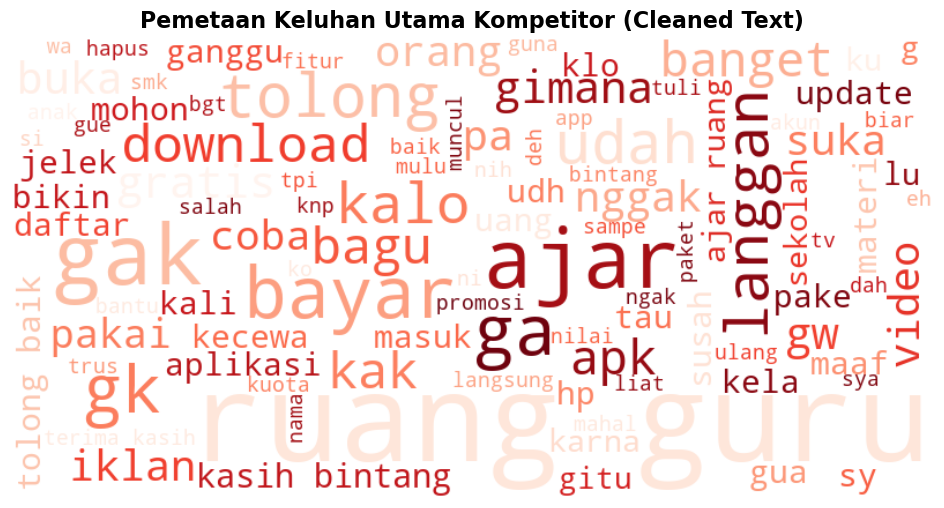

In [56]:
text_negatif_bersih = ' '.join(df_filtered[df_filtered['label'] == 'Negatif']['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif_bersih)

# Menampilkan visualisasi
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Pemetaan Keluhan Utama Kompetitor (Cleaned Text)', fontsize=16, fontweight='bold')
plt.show()

Celah Kelemahan (Sentimen Negatif): Pengguna sering mengeluhkan masalah akses finansial (kata "bayar", "mahal", "langgan") dan masalah teknis sistem (kata "buka", "masuk", "susah").

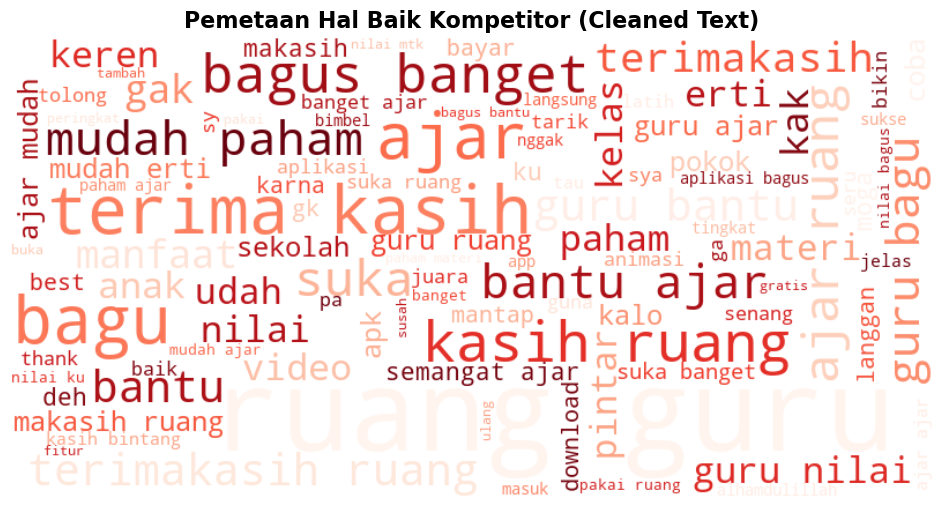

In [57]:
text_negatif_bersih = ' '.join(df_filtered[df_filtered['label'] == 'Positif']['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif_bersih)

# Menampilkan visualisasi
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Pemetaan Hal Baik Kompetitor (Cleaned Text)', fontsize=16, fontweight='bold')
plt.show()

Kekuatan Utama (Sentimen Positif): Pengguna sangat mengapresiasi platform ini karena dinilai sangat membantu kemudahan proses belajar. Hal ini ditunjukkan oleh dominasi kata "bantu", "paham", "mudah", "bagus", dan "keren" pada ulasan. Selain itu, banyak pengguna yang secara eksplisit mengekspresikan kepuasan mereka dengan kata "terima kasih" kepada fitur "ajar" dari platform Ruangguru.